## 📎 Code this notebook uses
*(full map of every notebook → [`README.md`](README.md))*

- **Engine — `src/lunar/`:** `config`, `grid`, `solver`, `_bootstrap`, `plotting`
- **Compute — `pipeline/compute/`:** `benchmark_cpp`

> `benchmark_cpp` builds + runs the **C++ port** `cpp/solver.cpp` and checks it matches the Python solver


# 07 — Driving the C++ solver from a notebook

**How the "ported C++ version" works, in one picture:**

```
Python (this notebook)                         C++ (code/cpp/solver.cpp)
──────────────────────                         ──────────────────────────
build grid, forcing, constants ──┐
                                 ├─► input.bin ──► ./lunar_solver ──► output.bin ──┐
                                 │   (one binary blob: sizes,                      │
                                 │    arrays, 16 physics scalars)                  │
read T(z,t), compare, plot  ◄────┴─────────────────────────────────────────────────┘
```

- The C++ port is a **standalone 300-line program** — no Python inside it.
  It implements *exactly* the same algorithm as the compiled Python kernel
  (`solver._march_radiative_hayne`): Crank–Nicolson step, midpoint-Picard
  property sweeps, Newton surface balance, Thomas solve, and the
  cycle-closing wrap step. Same equations, same order of operations.
- Python stays the **driver**: it serialises the inputs into one binary
  blob, launches the executable with `subprocess`, and reads the
  temperature field back. That is why a "C++ notebook" is really a
  *Python* notebook orchestrating a C++ engine — the standard pattern in
  scientific computing. (A true C++-kernel notebook exists — xeus-cling —
  but it's a heavyweight install and buys nothing here.)
- **Trust but verify:** the two implementations are compared every run;
  they agree to ~1e-12 K (double-precision round-off). One command does
  all of this outside the notebook too: `devcheck cpp`.


In [1]:
# setup: import the existing Python<->C++ harness (reused, not duplicated)
import sys, subprocess, numpy as np, matplotlib.pyplot as plt
from lunar._bootstrap import find_repo_root
CODE = find_repo_root()
sys.path.insert(0, str(CODE / "pipeline" / "compute"))
import benchmark_cpp as bc          # dump_inputs / run_cpp / run_py + constants

# rebuild the binary if solver.cpp changed since last compile
src, binp = CODE/"cpp"/"solver.cpp", CODE/"cpp"/"lunar_solver"
if not binp.exists() or src.stat().st_mtime > binp.stat().st_mtime:
    print("compiling:", " ".join(["clang++","-O3","-std=c++17","-o",binp.name,src.name]))
    subprocess.run(["clang++","-O3","-std=c++17","-o",str(binp),str(src)], check=True)
print("binary ready:", binp)

binary ready: /Users/rp3gregorio/Developer/Lunar-Clean/code/cpp/lunar_solver


In [2]:
# run BOTH implementations on identical inputs and compare
import functools, tempfile, pathlib
from lunar.config import SITES, GRID, DT_STEP
from lunar.grid import make_geometric_grid
from lunar.solver import standard_insolation, periodic_time_grid

N_LUN = 5                                   # EDIT ME: lunations to march
site  = SITES["A15"]                        # EDIT ME: "A15" or "A17"

g = make_geometric_grid(**GRID)
t = periodic_time_grid(DT_STEP)
insol = standard_insolation(site["lat"], t)
T_init = np.full(g.z_mid.size, site["T_MEAN_EFF"])

with tempfile.TemporaryDirectory() as td:
    inp, outp = pathlib.Path(td)/"in.bin", pathlib.Path(td)/"out.bin"
    bc.dump_inputs(inp, g, t, insol, T_init, site, N_LUN)
    s_cpp, T_cpp = bc.run_cpp(inp, outp, g.z_mid.size, t.size)
s_py, T_py = bc.run_py(g, t, insol, T_init, site, N_LUN, fast=True)

diff = np.max(np.abs(T_py - T_cpp))
print(f"C++   : {s_cpp*1e3/N_LUN:6.2f} ms/lunation")
print(f"python: {s_py*1e3/N_LUN:6.2f} ms/lunation  (compiled njit kernel)")
# NB: at small N_LUN the Python ms/lun is inflated by one-time jit
# compilation (~amortised away at N_LUN>=50; steady rate ~4.4 ms/lun
# vs C++ ~3.0 — see results/cpp_benchmark.json for the fair numbers).
print(f"max |T_py - T_cpp| = {diff:.2e} K   {'AGREE' if diff < 1e-9 else 'DIVERGED!'}")

C++   :   3.69 ms/lunation
python:  81.36 ms/lunation  (compiled njit kernel)
max |T_py - T_cpp| = 1.17e-12 K   AGREE


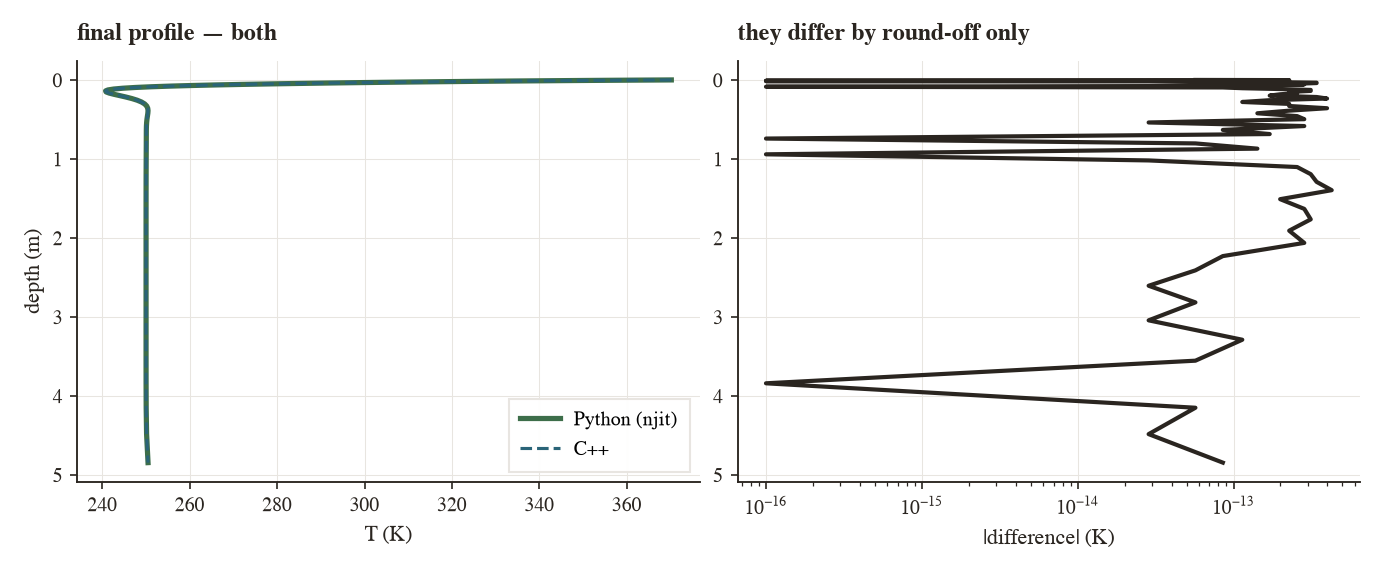

In [3]:
# see the agreement: final-time profiles overlaid + the difference
from lunar.plotting.style import C_A15, C_TEAL, C_CHAR, C_GRID, fmt_axis
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.6), constrained_layout=True)
a1.plot(T_py[:, -1],  g.z_mid, "-",  color=C_A15, lw=2.5, label="Python (njit)")
a1.plot(T_cpp[:, -1], g.z_mid, "--", color=C_TEAL, lw=1.5, label="C++")
a1.invert_yaxis()
fmt_axis(a1, xlabel="T (K)", ylabel="depth (m)", title="final profile — both")
a1.legend(frameon=True, edgecolor=C_GRID)
a2.semilogx(np.abs(T_py[:, -1] - T_cpp[:, -1]) + 1e-16, g.z_mid, color=C_CHAR)
a2.invert_yaxis()
fmt_axis(a2, xlabel="|difference| (K)", title="they differ by round-off only")
plt.show()

## Editing the C++ side
The whole engine is one file: `code/cpp/solver.cpp` (plain C++17, zero
dependencies). The house rule — **two languages, one truth**: any change
to the physics march must be made in *both* `lunar/solver.py` (njit
kernel) and `solver.cpp`, then re-run this notebook (or `devcheck cpp`)
and demand the ~1e-12 K agreement before trusting either.